# GTFS Public Transport Dataset

The main dataset is the GTFS timetable dataset provided by Swiss Federal Railways via OpenTransportData. It contains the complete public transport schedule for Switzerland.

Dataset: https://data.opentransportdata.swiss/fr/dataset/timetable-2026-gtfs2020

## Structure : 

The dataset is composed of multiple CSV files describing different aspects of the network:
- `stops.txt` : geographic coordinates of stops and stations
- `routes.txt`: transport lines and operators
- `trips.txt`: individual vehicle trips
- `stop_times.txt`: schedule of arrivals and departures
- `transfers.txt`: transfer times between stops

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PATH = Path("../data/gtfs_fp2026_20260311")

stops = pd.read_csv(PATH / "stops.txt")
routes = pd.read_csv(PATH / "routes.txt")
trips = pd.read_csv(PATH / "trips.txt")
stop_times = pd.read_csv(PATH / "stop_times.txt")

/var/folders/vh/qxbx1gcd7xb1gcxc5z2l5nmw0000gn/T/ipykernel_8149/375067335.py:7: DtypeWarning: Columns (0: parent_station, 1: platform_code) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(PATH / "stops.txt")


In [ ]:
print("Stops:", stops.shape)
print("Routes:", routes.shape)
print("Trips:", trips.shape)
print("Stop times:", stop_times.shape)

Stops: (95675, 8)
Routes: (4817, 6)
Trips: (1153656, 9)
Stop times: (18567250, 7)


### Total Number of Stops in Switzerland

Stops correspond to stations, bus stops, tram stops, ...

In [ ]:
total_stops = stops["stop_id"].nunique()
print("Total number of stops:", total_stops)

Total number of stops: 95675


### Distribution of Transport Modes

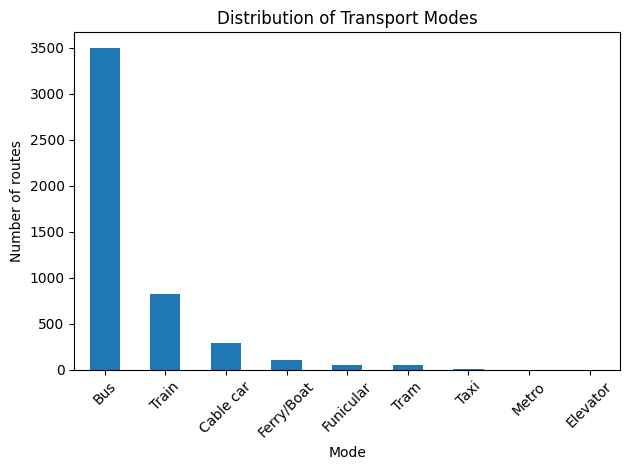

In [ ]:
route_type_map = {
    0: "Tram",
    1: "Metro",
    2: "Train",
    3: "Bus",
    4: "Ferry/Boat",
    5: "Cable car",
    6: "Cable car",
    7: "Funicular",

    700: "Bus",
    702: "Bus",
    705: "Bus",
    710: "Bus",
    715: "Bus",
    201: "Bus",
    202: "Bus",

    900: "Tram",
    401: "Metro",

    100: "Train",
    101: "Train",
    102: "Train",
    103: "Train",
    104: "Train",
    105: "Train",
    106: "Train",
    107: "Train",
    109: "Train",
    116: "Train",
    117: "Train",

    1000: "Ferry/Boat",

    1100: "Airplane",

    1300: "Cable car",
    1303: "Elevator",

    1400: "Funicular",

    1500: "Taxi",
    1700: "Unknown",
}

routes["mode"] = routes["route_type"].map(route_type_map).fillna("Other")

# Count routes by broad category
mode_counts = routes["mode"].value_counts().sort_values(ascending=False)

mode_counts.plot(kind="bar")
plt.title("Distribution of Transport Modes")
plt.xlabel("Mode")
plt.ylabel("Number of routes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
mode_summary = (
    routes.groupby(["route_type", "mode"])
    .size()
    .reset_index(name="n_routes")
    .sort_values(["mode", "n_routes"], ascending=[True, False])
)

mode_summary.head(30)

,route_type,mode,n_routes
11,700,Bus,3183
13,705,Bus,216
15,715,Bus,77
12,702,Bus,12
14,710,Bus,2
9,202,Bus,1
18,1300,Cable car,290
19,1303,Elevator,2
17,1000,Ferry/Boat,103
20,1400,Funicular,53


### Number of trips per route

In [ ]:
trips_per_route = trips.groupby("route_id")["trip_id"].count()

print("Average trips per route:", trips_per_route.mean())
print("Max trips per route:", trips_per_route.max())
print("Min trips per route:", trips_per_route.min())

Average trips per route: 239.4967822296035
Max trips per route: 26722
Min trips per route: 1


### Number of departures per station

In [ ]:
departures_per_station = stop_times.groupby("stop_id")["trip_id"].count()
departures_per_station.describe()

count    60537.000000
mean       306.709120
std        860.170613
min          1.000000
25%         23.000000
50%         64.000000
75%        219.000000
max      34756.000000
Name: trip_id, dtype: float64

In [ ]:
top_departures = departures_per_station.sort_values(ascending=False).head(10)

top_departures = top_departures.reset_index()
top_departures = top_departures.merge(stops[["stop_id","stop_name"]], on="stop_id")

top_departures

,stop_id,trip_id,stop_name
0,8505095:0:D,34756,"Schwyz, Zentrum"
1,8590052:0:10000,19497,"Ostermundigen, Rüti"
2,8505098:0:A,19316,"Brunnen, Bahnhof"
3,8595932:0:10000,19024,"Schliern, Bus-Endstation"
4,8577430:0:10000,18121,"Ibach, Mythen Center"
5,8577432:0:10000,18116,"Schwyz, Steisteg"
6,8577431:0:10000,16021,"Schwyz, Lücken"
7,8577430:0:10001,16016,"Ibach, Mythen Center"
8,8577205:0:A,14800,"Küssnacht am Rigi, Bahnhof"
9,8505095:0:A,14571,"Schwyz, Zentrum"
